<a href="https://colab.research.google.com/github/RIR-Is-Everywhere/Algorithm-_project/blob/main/Student%20Dropout%20Prediction%20Thesis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

*italicised text*

In [2]:
!pip install xgboost lightgbm catboost shap imbalanced-learn


In [16]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier, StackingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                           f1_score, roc_auc_score, roc_curve, confusion_matrix,
                           classification_report)
from sklearn.impute import SimpleImputer
from sklearn.multiclass import OneVsRestClassifier  # Added this import
import xgboost as xgb
import lightgbm as lgb
import shap

print('Libraries imported')

Libraries imported


In [7]:
df = pd.read_csv('/content/data.csv', sep=';')
df.head()
print(df.shape)
df.head()
try:
    df = pd.read_csv(file_path, sep=';', encoding='utf-8-sig')
    print("✅ Data loaded successfully!")
except:
    # If file is in Colab's local storage
    df = pd.read_csv('data.csv', sep=';', encoding='utf-8-sig')
    print("✅ Data loaded from local storage!")

# Display basic information
print("\n" + "="*50)
print("DATASET OVERVIEW")
print("="*50)
print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nTarget variable distribution:")
print(df['Target'].value_counts())
print(f"\nTarget percentages:")
print(df['Target'].value_counts(normalize=True) * 100)

# Display first few rows
print("\n" + "="*50)
print("FIRST 5 ROWS")
print("="*50)
df.head()

(4424, 37)
✅ Data loaded from local storage!

DATASET OVERVIEW
Shape: (4424, 37)

Columns: ['Marital status', 'Application mode', 'Application order', 'Course', 'Daytime/evening attendance\t', 'Previous qualification', 'Previous qualification (grade)', 'Nacionality', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation", 'Admission grade', 'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'Age at enrollment', 'International', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem 

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [8]:
print("="*50)
print("DATA PREPROCESSING")
print("="*50)

# Check for missing values
print("\nMissing values per column:")
missing = df.isnull().sum()
print(missing[missing > 0] if any(missing > 0) else "No missing values found!")

# Handle the target variable - encode it
le_target = LabelEncoder()
df['Target_encoded'] = le_target.fit_transform(df['Target'])

print(f"\nTarget encoding:")
for i, label in enumerate(le_target.classes_):
    print(f"  {label} -> {i}")

# Identify numerical and categorical columns
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numerical_cols.remove('Target_encoded')  # Remove encoded target

categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
categorical_cols.remove('Target')  # Remove original target

print(f"\nNumerical columns ({len(numerical_cols)}): {numerical_cols[:10]}...")
print(f"Categorical columns ({len(categorical_cols)}): {categorical_cols}")

# Handle missing values in numerical columns (if any)
if df[numerical_cols].isnull().sum().sum() > 0:
    imputer = SimpleImputer(strategy='median')
    df[numerical_cols] = imputer.fit_transform(df[numerical_cols])
    print("\n✅ Missing values in numerical columns imputed with median")

# Encode categorical variables
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col + '_encoded'] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

# Create feature matrix
encoded_cat_cols = [col + '_encoded' for col in categorical_cols]
feature_cols = numerical_cols + encoded_cat_cols

X = df[feature_cols]
y = df['Target_encoded']

print(f"\n✅ Feature matrix shape: {X.shape}")
print(f"✅ Target shape: {y.shape}")

DATA PREPROCESSING

Missing values per column:
No missing values found!

Target encoding:
  Dropout -> 0
  Enrolled -> 1
  Graduate -> 2

Numerical columns (36): ['Marital status', 'Application mode', 'Application order', 'Course', 'Daytime/evening attendance\t', 'Previous qualification', 'Previous qualification (grade)', 'Nacionality', "Mother's qualification", "Father's qualification"]...
Categorical columns (0): []

✅ Feature matrix shape: (4424, 36)
✅ Target shape: (4424,)


In [9]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("="*50)
print("TRAIN-TEST SPLIT")
print("="*50)
print(f"Training set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")
print(f"\nTraining set class distribution:")
print(y_train.value_counts().sort_index())
print(f"\nTest set class distribution:")
print(y_test.value_counts().sort_index())

# Scale numerical features
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Only scale numerical columns
X_train_scaled[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test_scaled[numerical_cols] = scaler.transform(X_test[numerical_cols])

print("\n✅ Features scaled successfully!")

TRAIN-TEST SPLIT
Training set size: (3539, 36)
Test set size: (885, 36)

Training set class distribution:
Target_encoded
0    1137
1     635
2    1767
Name: count, dtype: int64

Test set class distribution:
Target_encoded
0    284
1    159
2    442
Name: count, dtype: int64

✅ Features scaled successfully!


In [10]:
def evaluate_model(model, X_train, y_train, X_test, y_test, model_name):
    """
    Train and evaluate a model, return metrics
    """
    # Train the model
    model.fit(X_train, y_train)

    # Make predictions
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)

    # For multi-class, use weighted average
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    # ROC-AUC for multi-class (one-vs-rest)
    roc_auc = roc_auc_score(y_test, y_pred_proba, multi_class='ovr', average='weighted')

    # Cross-validation score
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')

    # Store results
    results = {
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1,
        'ROC-AUC': roc_auc,
        'CV Mean': cv_scores.mean(),
        'CV Std': cv_scores.std()
    }

    # Print results
    print(f"\n{'='*50}")
    print(f"{model_name} RESULTS")
    print(f"{'='*50}")
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print(f"ROC-AUC:   {roc_auc:.4f}")
    print(f"CV Score:  {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

    return results, y_pred, y_pred_proba

In [20]:
# Store all results
all_results = []
all_predictions = {}
all_probabilities = {}

# Dictionary to store trained models for later use
trained_models = {}

# ============================================
# 1. LOGISTIC REGRESSION
# ============================================
print("\n" + "🔥"*20)
print("TRAINING LOGISTIC REGRESSION")
print("🔥"*20)

lr_model = LogisticRegression(max_iter=1000, random_state=42, multi_class='ovr')
lr_results, lr_pred, lr_proba = evaluate_model(
    lr_model, X_train_scaled, y_train, X_test_scaled, y_test, "Logistic Regression"
)
all_results.append(lr_results)
all_predictions['Logistic Regression'] = lr_pred
all_probabilities['Logistic Regression'] = lr_proba
trained_models['Logistic Regression'] = lr_model

# ============================================
# 2. RANDOM FOREST
# ============================================
print("\n" + "🌲"*20)
print("TRAINING RANDOM FOREST")
print("🌲"*20)

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
rf_results, rf_pred, rf_proba = evaluate_model(
    rf_model, X_train_scaled, y_train, X_test_scaled, y_test, "Random Forest"
)
all_results.append(rf_results)
all_predictions['Random Forest'] = rf_pred
all_probabilities['Random Forest'] = rf_proba
trained_models['Random Forest'] = rf_model

# ============================================
# 3. GRADIENT BOOSTING
# ============================================
print("\n" + "📈"*20)
print("TRAINING GRADIENT BOOSTING")
print("📈"*20)

gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)
gb_results, gb_pred, gb_proba = evaluate_model(
    gb_model, X_train_scaled, y_train, X_test_scaled, y_test, "Gradient Boosting"
)
all_results.append(gb_results)
all_predictions['Gradient Boosting'] = gb_pred
all_probabilities['Gradient Boosting'] = gb_proba
trained_models['Gradient Boosting'] = gb_model

# ============================================
# 4. XGBOOST
# ============================================
print("\n" + "⚡"*20)
print("TRAINING XGBOOST")
print("⚡"*20)

xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    use_label_encoder=False,
    eval_metric='mlogloss'
)
xgb_results, xgb_pred, xgb_proba = evaluate_model(
    xgb_model, X_train_scaled, y_train, X_test_scaled, y_test, "XGBoost"
)
all_results.append(xgb_results)
all_predictions['XGBoost'] = xgb_pred
all_probabilities['XGBoost'] = xgb_proba
trained_models['XGBoost'] = xgb_model

# ============================================
# 5. LIGHTGBM
# ============================================
print("\n" + "💡"*20)
print("TRAINING LIGHTGBM")
print("💡"*20)

lgb_model = lgb.LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    verbose=-1
)
lgb_results, lgb_pred, lgb_proba = evaluate_model(
    lgb_model, X_train_scaled, y_train, X_test_scaled, y_test, "LightGBM"
)
all_results.append(lgb_results)
all_predictions['LightGBM'] = lgb_pred
all_probabilities['LightGBM'] = lgb_proba
trained_models['LightGBM'] = lgb_model

# ============================================
# CREATE ENSEMBLE MODELS
# ============================================

print("\n" + "🤝"*20)
print("CREATING ENSEMBLE MODELS")
print("🤝"*20)

# Voting Classifier
print("\n" + "="*50)
print("TRAINING VOTING ENSEMBLE")
print("="*50)

voting_clf = VotingClassifier(
    estimators=[
        ('rf', rf_model),
        ('xgb', xgb_model),
        ('lgb', lgb_model)
    ],
    voting='soft'
)
voting_results, voting_pred, voting_proba = evaluate_model(
    voting_clf, X_train_scaled, y_train, X_test_scaled, y_test, "Voting Ensemble"
)
all_results.append(voting_results)
all_predictions['Voting Ensemble'] = voting_pred
all_probabilities['Voting Ensemble'] = voting_proba
trained_models['Voting Ensemble'] = voting_clf

# Stacking Classifier
print("\n" + "="*50)
print("TRAINING STACKING ENSEMBLE")
print("="*50)

stacking_clf = StackingClassifier(
    estimators=[
        ('rf', rf_model),
        ('xgb', xgb_model),
        ('lgb', lgb_model)
    ],
    final_estimator=LogisticRegression(max_iter=1000, multi_class='multinomial'),
    cv=5
)
stacking_results, stacking_pred, stacking_proba = evaluate_model(
    stacking_clf, X_train_scaled, y_train, X_test_scaled, y_test, "Stacking Ensemble"
)
all_results.append(stacking_results)
all_predictions['Stacking Ensemble'] = stacking_pred
all_probabilities['Stacking Ensemble'] = stacking_proba
trained_models['Stacking Ensemble'] = stacking_clf

# Optional: Print summary of all results including ensembles
print("\n" + "📊"*20)
print("FINAL SUMMARY - ALL MODELS (including ensembles)")
print("📊"*20)
results_df = pd.DataFrame(all_results)
print(results_df.to_string(index=False))


🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥
TRAINING LOGISTIC REGRESSION
🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥

Logistic Regression RESULTS
Accuracy:  0.7605
Precision: 0.7377
Recall:    0.7605
F1 Score:  0.7377
ROC-AUC:   0.8913
CV Score:  0.7629 (+/- 0.0078)

🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲
TRAINING RANDOM FOREST
🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲

Random Forest RESULTS
Accuracy:  0.7684
Precision: 0.7544
Recall:    0.7684
F1 Score:  0.7501
ROC-AUC:   0.9045
CV Score:  0.7706 (+/- 0.0114)

📈📈📈📈📈📈📈📈📈📈📈📈📈📈📈📈📈📈📈📈
TRAINING GRADIENT BOOSTING
📈📈📈📈📈📈📈📈📈📈📈📈📈📈📈📈📈📈📈📈

Gradient Boosting RESULTS
Accuracy:  0.7661
Precision: 0.7568
Recall:    0.7661
F1 Score:  0.7585
ROC-AUC:   0.9076
CV Score:  0.7734 (+/- 0.0107)

⚡⚡⚡⚡⚡⚡⚡⚡⚡⚡⚡⚡⚡⚡⚡⚡⚡⚡⚡⚡
TRAINING XGBOOST
⚡⚡⚡⚡⚡⚡⚡⚡⚡⚡⚡⚡⚡⚡⚡⚡⚡⚡⚡⚡

XGBoost RESULTS
Accuracy:  0.7650
Precision: 0.7541
Recall:    0.7650
F1 Score:  0.7554
ROC-AUC:   0.9068
CV Score:  0.7759 (+/- 0.0100)

💡💡💡💡💡💡💡💡💡💡💡💡💡💡💡💡💡💡💡💡
TRAINING LIGHTGBM
💡💡💡💡💡💡💡💡💡💡💡💡💡💡💡💡💡💡💡💡

LightGBM RESULTS
Accuracy:  0.7650
Precision: 0.7582
Recall:    0.7650
F1 Score:  0.7592
R


MODEL COMPARISON - SORTED BY ACCURACY
              Model  Accuracy  Precision   Recall  F1 Score  ROC-AUC  CV Mean   CV Std
  Stacking Ensemble  0.772881   0.765726 0.772881  0.766894 0.907793 0.776773 0.011656
    Voting Ensemble  0.770621   0.760987 0.770621  0.761095 0.909138 0.775360 0.007540
      Random Forest  0.768362   0.754413 0.768362  0.750055 0.904463 0.770559 0.011385
  Gradient Boosting  0.766102   0.756798 0.766102  0.758539 0.907604 0.773381 0.010728
           LightGBM  0.764972   0.758249 0.764972  0.759234 0.904343 0.772535 0.002494
            XGBoost  0.764972   0.754125 0.764972  0.755450 0.906818 0.775921 0.009992
Logistic Regression  0.760452   0.737669 0.760452  0.737735 0.891348 0.762929 0.007764

✅ Results saved to 'model_comparison_results.csv'


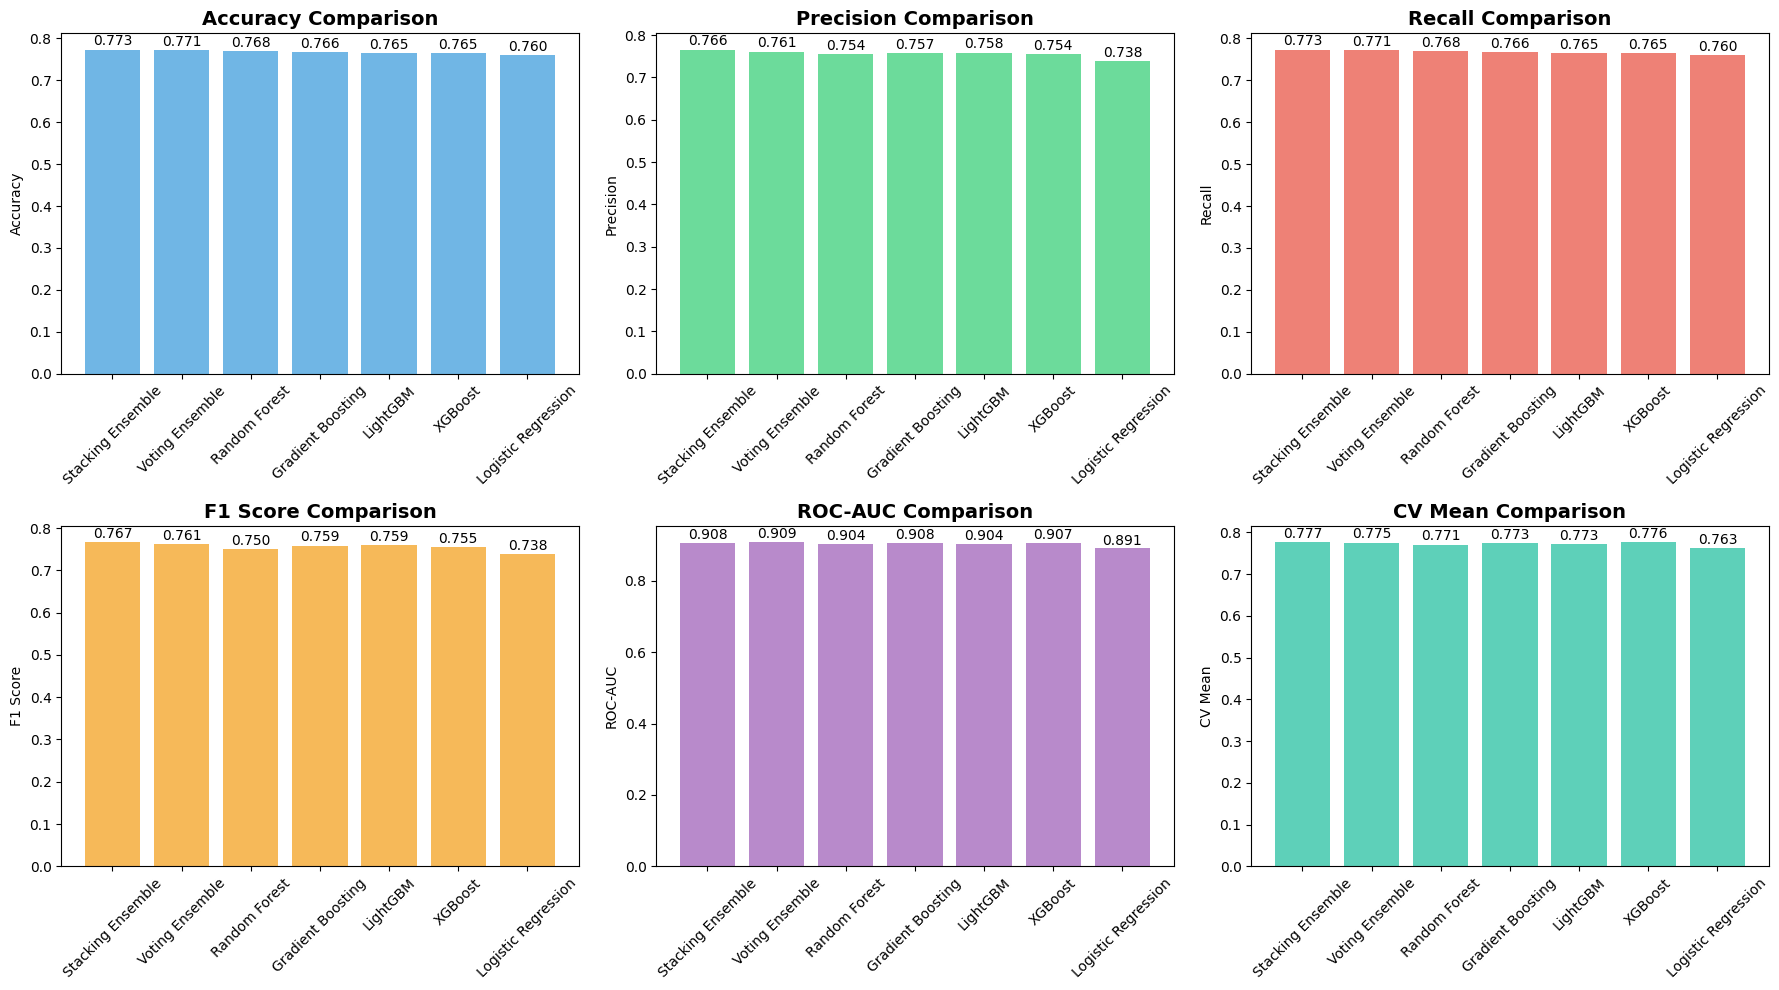

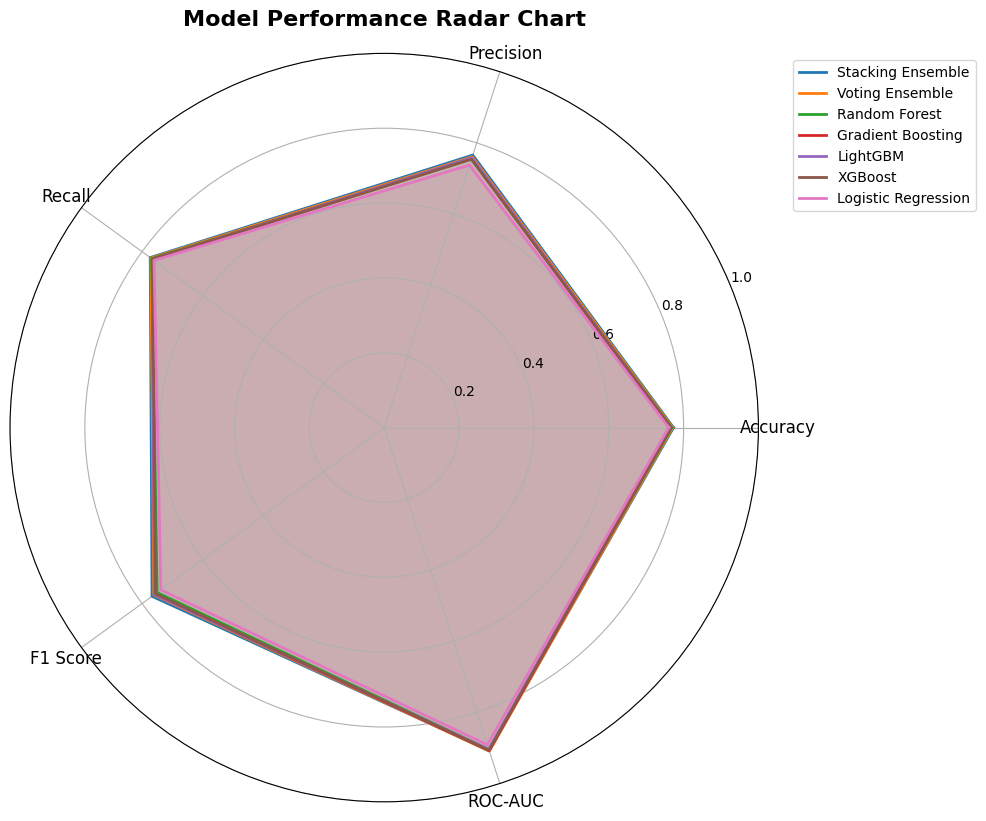

In [21]:
# Create comparison dataframe
comparison_df = pd.DataFrame(all_results)
comparison_df = comparison_df.sort_values('Accuracy', ascending=False)

print("\n" + "="*70)
print("MODEL COMPARISON - SORTED BY ACCURACY")
print("="*70)
print(comparison_df.to_string(index=False))

# Save comparison to CSV
comparison_df.to_csv('model_comparison_results.csv', index=False)
print("\n✅ Results saved to 'model_comparison_results.csv'")

# Visual comparison
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC', 'CV Mean']
colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6', '#1abc9c']

for i, (metric, color) in enumerate(zip(metrics, colors)):
    axes[i].bar(comparison_df['Model'], comparison_df[metric], color=color, alpha=0.7)
    axes[i].set_title(f'{metric} Comparison', fontsize=14, fontweight='bold')
    axes[i].set_ylabel(metric)
    axes[i].tick_params(axis='x', rotation=45)

    # Add value labels on bars
    for j, v in enumerate(comparison_df[metric]):
        axes[i].text(j, v + 0.01, f'{v:.3f}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('model_comparison_charts.png', dpi=300, bbox_inches='tight')
plt.show()

# Radar chart for holistic comparison
from math import pi

# Prepare data for radar chart
categories = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']
N = len(categories)

# Create angles
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))

# Plot each model
for idx, row in comparison_df.iterrows():
    values = row[categories].tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=2, linestyle='solid', label=row['Model'])
    ax.fill(angles, values, alpha=0.1)

# Set category labels
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=12)
ax.set_ylim(0, 1)
ax.set_title('Model Performance Radar Chart', fontsize=16, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))

plt.tight_layout()
plt.savefig('radar_chart_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

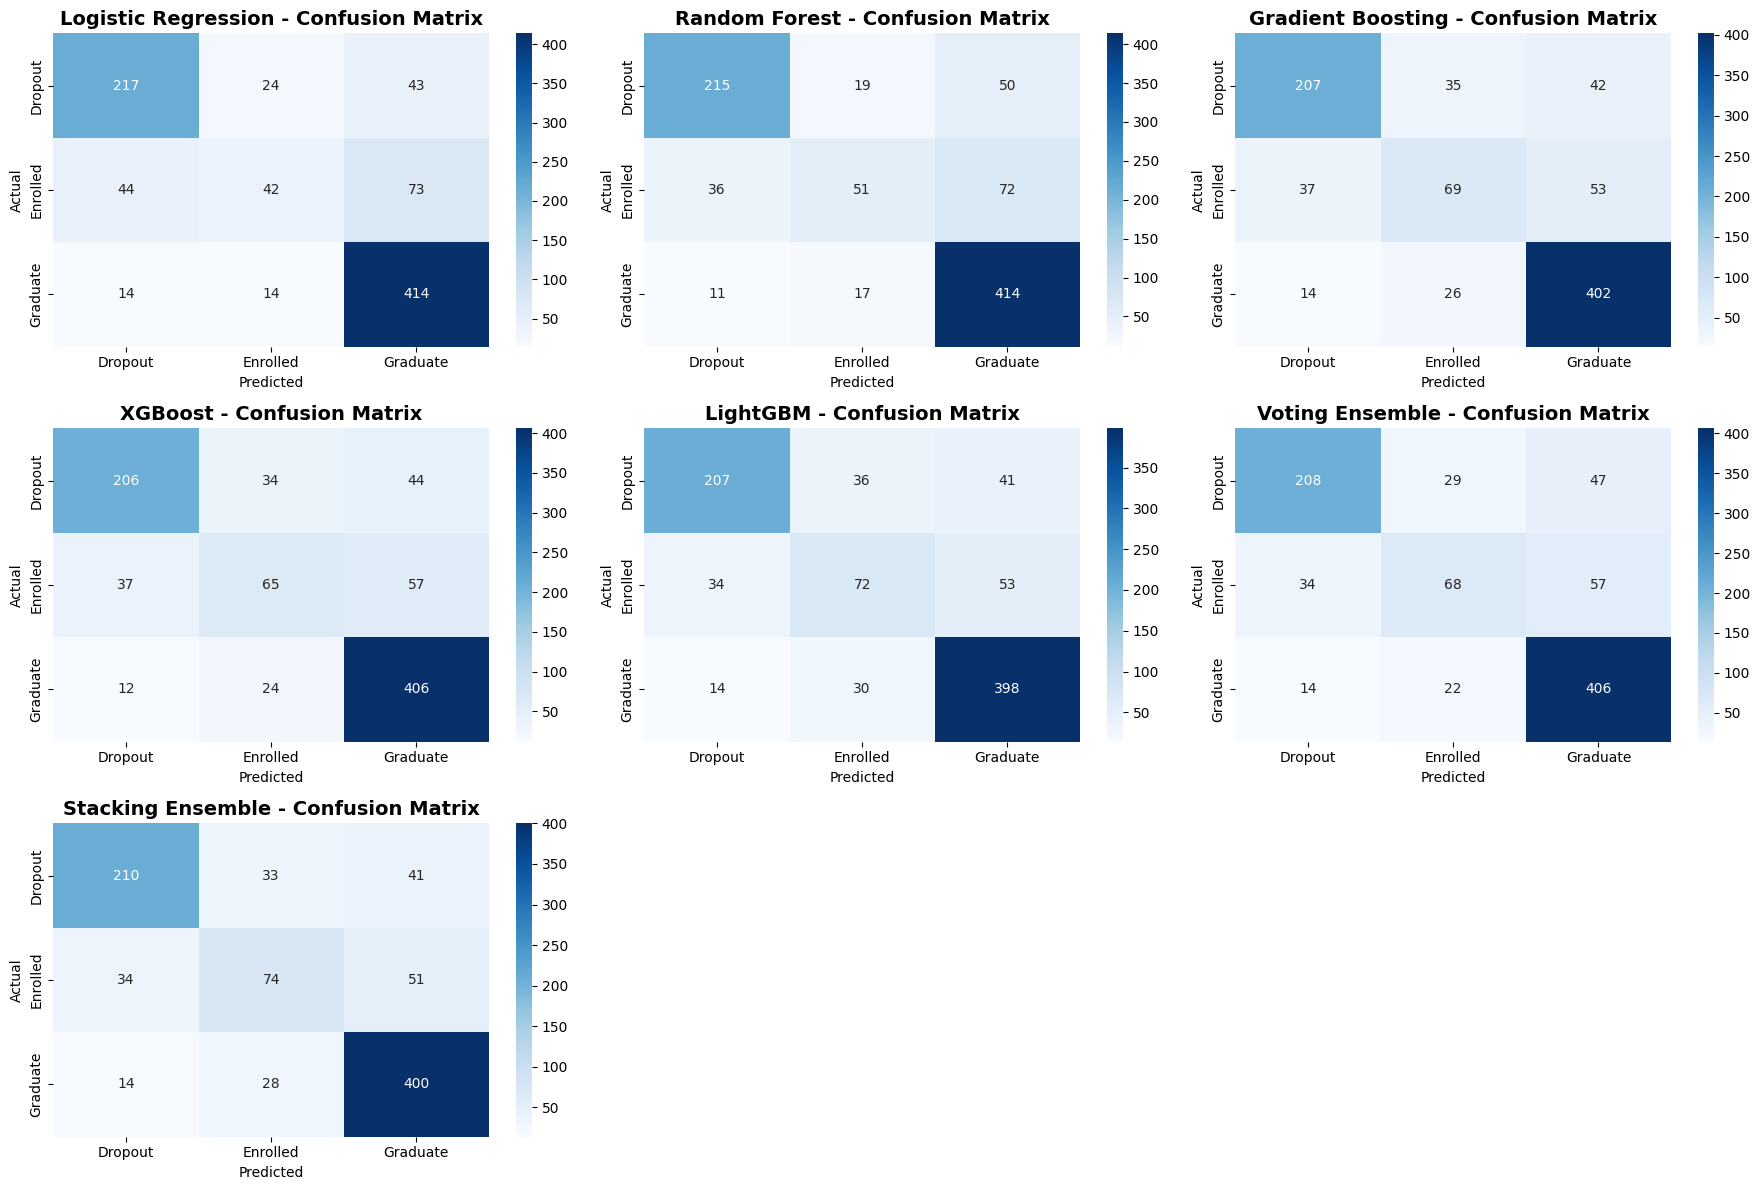

In [22]:
# ============================================
# CONFUSION MATRICES FOR ALL MODELS
# ============================================
# Calculate number of models and create subplot grid
n_models = len(all_predictions)  # Should be 7 models total
n_cols = 3
n_rows = (n_models + n_cols - 1) // n_cols  # Ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.ravel() if n_rows > 1 else [axes] if n_cols == 1 else axes.ravel()

for idx, (model_name, y_pred) in enumerate(all_predictions.items()):
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=le_target.classes_, yticklabels=le_target.classes_)
    axes[idx].set_title(f'{model_name} - Confusion Matrix', fontsize=14, fontweight='bold')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

# Hide any unused subplots
for idx in range(len(all_predictions), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.savefig('confusion_matrices_all_models.png', dpi=300, bbox_inches='tight')
plt.show()

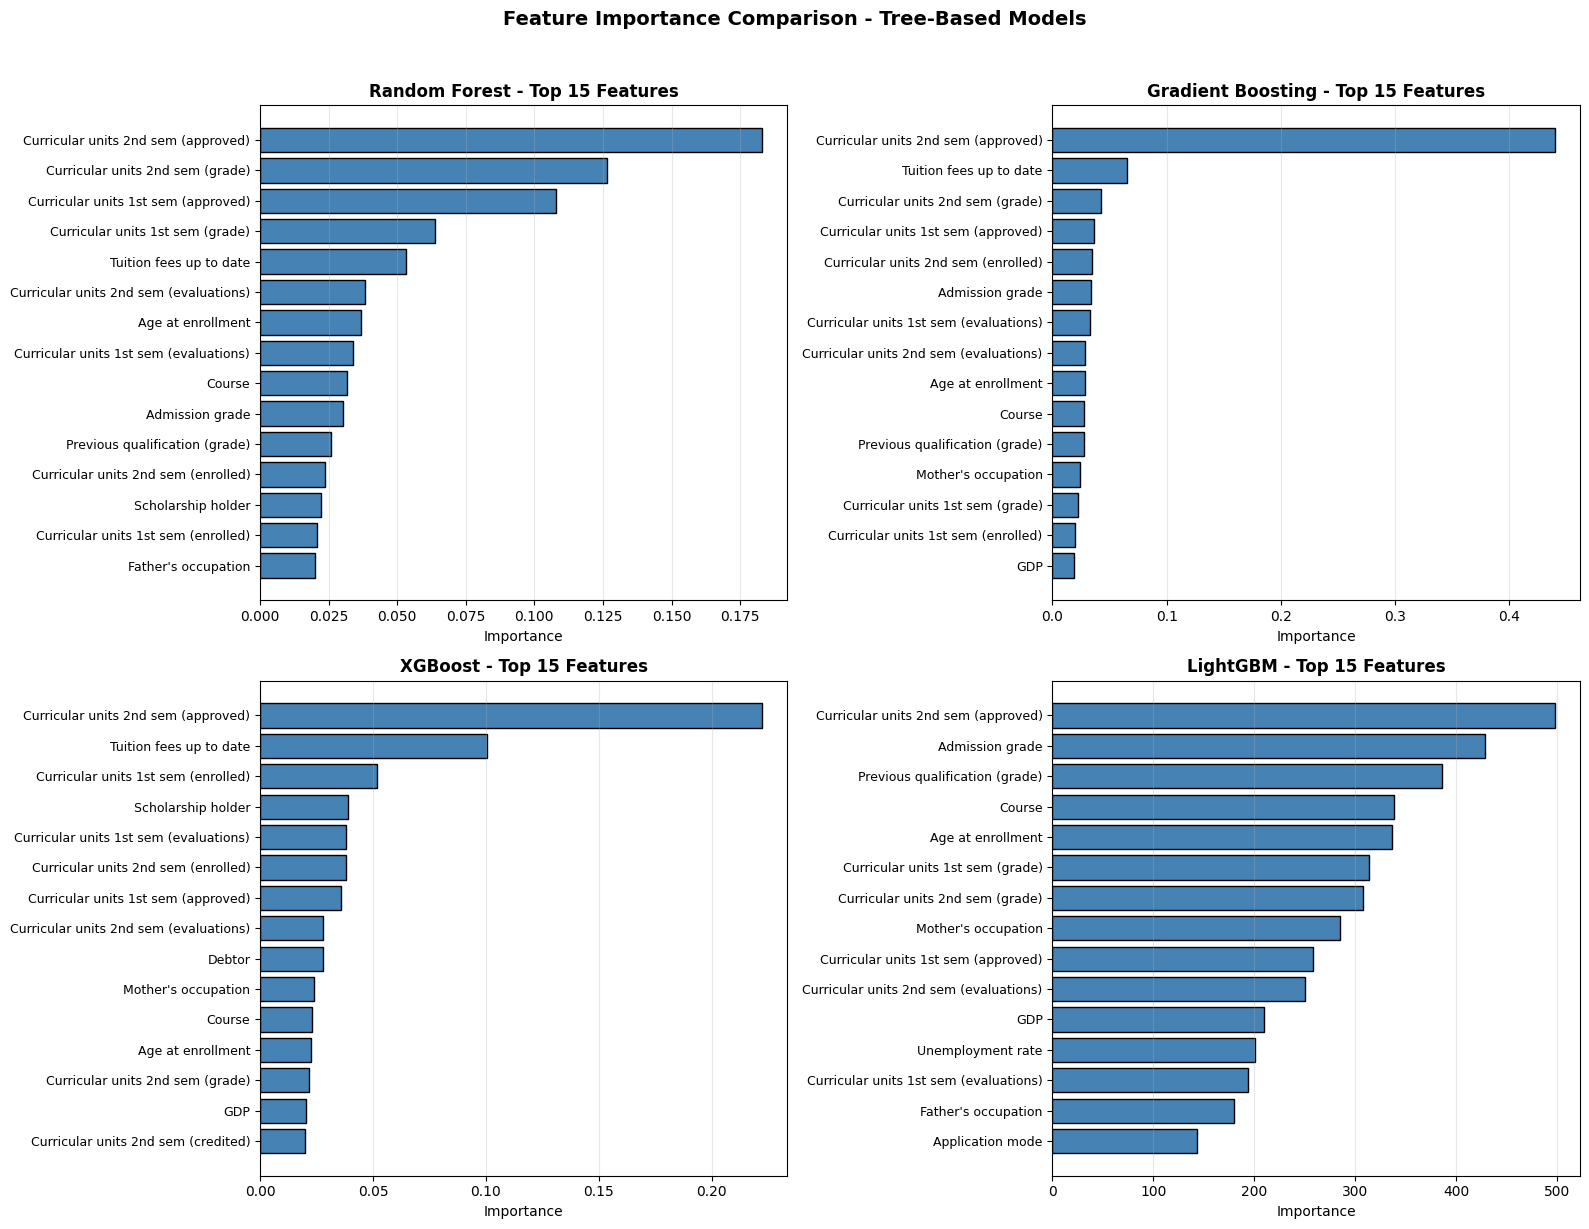


TOP 10 FEATURES COMPARISON ACROSS MODELS


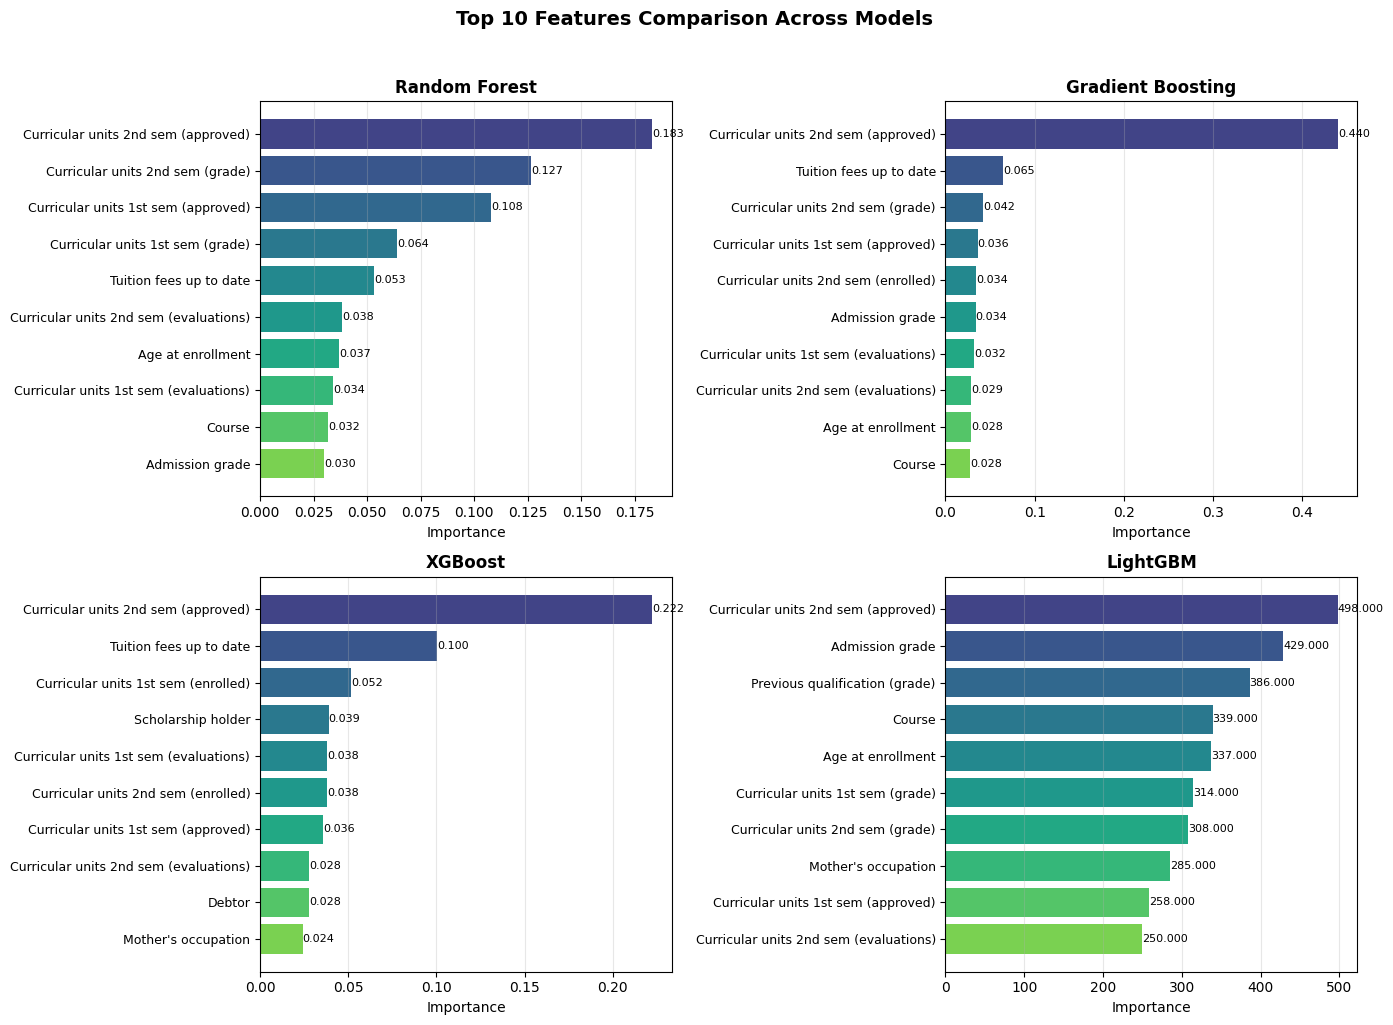


AGGREGATE FEATURE IMPORTANCE HEATMAP


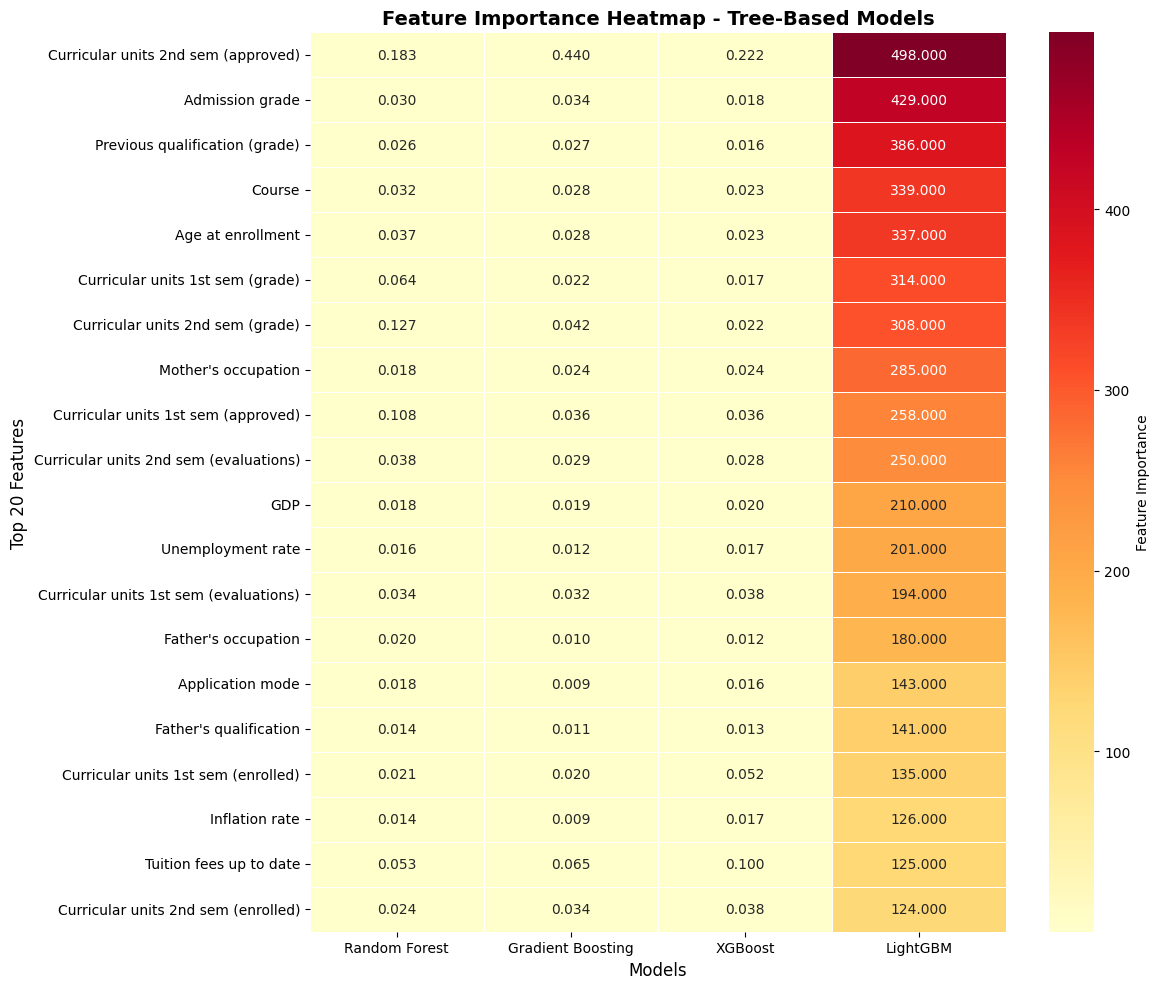


SUMMARY: TOP 5 FEATURES PER MODEL

📊 Random Forest:
   1. Curricular units 2nd sem (approved): 0.1831
   2. Curricular units 2nd sem (grade): 0.1265
   3. Curricular units 1st sem (approved): 0.1079
   4. Curricular units 1st sem (grade): 0.0639
   5. Tuition fees up to date: 0.0534

📊 Gradient Boosting:
   1. Curricular units 2nd sem (approved): 0.4397
   2. Tuition fees up to date: 0.0650
   3. Curricular units 2nd sem (grade): 0.0425
   4. Curricular units 1st sem (approved): 0.0362
   5. Curricular units 2nd sem (enrolled): 0.0342

📊 XGBoost:
   1. Curricular units 2nd sem (approved): 0.2224
   2. Tuition fees up to date: 0.1004
   3. Curricular units 1st sem (enrolled): 0.0518
   4. Scholarship holder: 0.0389
   5. Curricular units 1st sem (evaluations): 0.0380

📊 LightGBM:
   1. Curricular units 2nd sem (approved): 498.0000
   2. Admission grade: 429.0000
   3. Previous qualification (grade): 386.0000
   4. Course: 339.0000
   5. Age at enrollment: 337.0000

LOGISTIC REGRESSION 

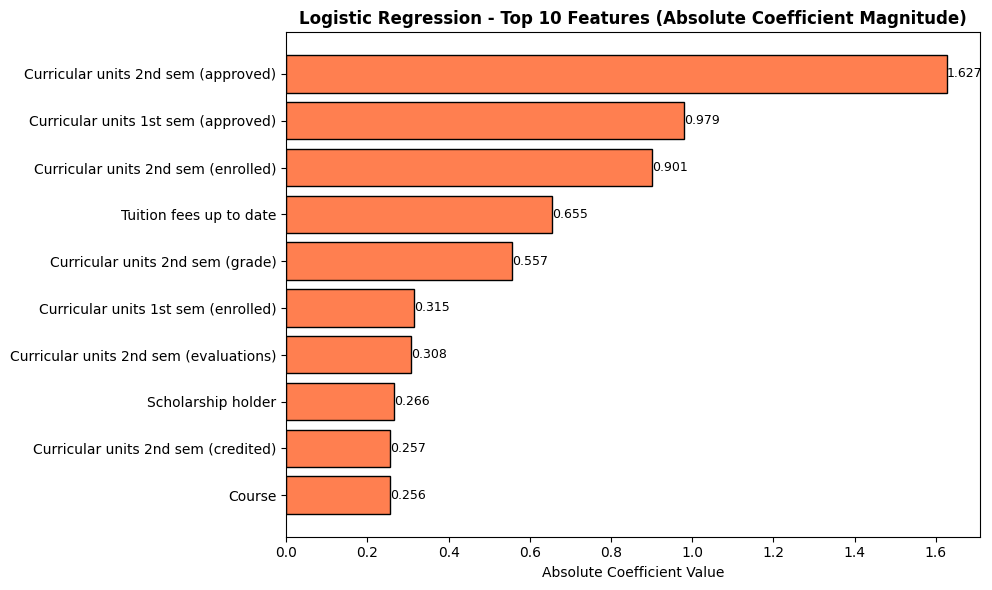

In [23]:
# ============================================
# FEATURE IMPORTANCE ANALYSIS - ALL MODELS
# ============================================

# Define all tree-based models (models that support feature_importances_)
tree_models = {
    'Random Forest': trained_models.get('Random Forest'),
    'Gradient Boosting': trained_models.get('Gradient Boosting'),
    'XGBoost': trained_models.get('XGBoost'),
    'LightGBM': trained_models.get('LightGBM')
}

# Also check for ensemble models that might have feature importances
ensemble_models = {
    'Voting Ensemble': trained_models.get('Voting Ensemble'),
    'Stacking Ensemble': trained_models.get('Stacking Ensemble')
}

feature_names = X.columns.tolist()

# Method 1: Individual subplots for each tree model
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()

valid_models = []
for idx, (model_name, model) in enumerate(tree_models.items()):
    if model is not None and hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_

        # Sort features by importance
        indices = np.argsort(importances)[::-1][:15]  # Top 15 features

        axes[idx].barh(range(len(indices)), importances[indices], align='center',
                       color='steelblue', edgecolor='black')
        axes[idx].set_yticks(range(len(indices)))
        axes[idx].set_yticklabels([feature_names[i] for i in indices], fontsize=9)
        axes[idx].invert_yaxis()
        axes[idx].set_title(f'{model_name} - Top 15 Features', fontsize=12, fontweight='bold')
        axes[idx].set_xlabel('Importance', fontsize=10)
        axes[idx].grid(axis='x', alpha=0.3)
        valid_models.append(model_name)
    else:
        axes[idx].set_visible(False)
        print(f"⚠️ {model_name} not available or doesn't have feature_importances_")

# Hide any unused subplots
for idx in range(len(valid_models), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Feature Importance Comparison - Tree-Based Models', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('feature_importance_tree_models.png', dpi=300, bbox_inches='tight')
plt.show()

# Method 2: Side-by-side comparison of top features across models
print("\n" + "="*60)
print("TOP 10 FEATURES COMPARISON ACROSS MODELS")
print("="*60)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for idx, (model_name, model) in enumerate(tree_models.items()):
    if model is not None and hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_

        # Get top 10 features
        indices = np.argsort(importances)[::-1][:10]
        top_features = [feature_names[i] for i in indices]
        top_importances = importances[indices]

        # Create horizontal bar chart
        bars = axes[idx].barh(range(len(top_features)), top_importances,
                              color=plt.cm.viridis(np.linspace(0.2, 0.8, len(top_features))))
        axes[idx].set_yticks(range(len(top_features)))
        axes[idx].set_yticklabels(top_features, fontsize=9)
        axes[idx].invert_yaxis()
        axes[idx].set_title(f'{model_name}', fontsize=12, fontweight='bold')
        axes[idx].set_xlabel('Importance', fontsize=10)

        # Add value labels on bars
        for i, (bar, val) in enumerate(zip(bars, top_importances)):
            axes[idx].text(val, bar.get_y() + bar.get_height()/2,
                          f'{val:.3f}', va='center', ha='left', fontsize=8)

        axes[idx].grid(axis='x', alpha=0.3)

plt.suptitle('Top 10 Features Comparison Across Models', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('feature_importance_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# Method 3: Aggregate feature importance heatmap
print("\n" + "="*60)
print("AGGREGATE FEATURE IMPORTANCE HEATMAP")
print("="*60)

# Create DataFrame for feature importances across all models
importance_df = pd.DataFrame()
for model_name, model in tree_models.items():
    if model is not None and hasattr(model, 'feature_importances_'):
        importance_df[model_name] = model.feature_importances_

# Add index as feature names
importance_df.index = feature_names

# Get top 20 features across all models (by mean importance)
top_features = importance_df.mean(axis=1).nlargest(20).index
importance_df_top = importance_df.loc[top_features]

# Plot heatmap
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(importance_df_top, annot=True, fmt='.3f', cmap='YlOrRd',
            cbar_kws={'label': 'Feature Importance'}, ax=ax, linewidths=0.5)
ax.set_title('Feature Importance Heatmap - Tree-Based Models', fontsize=14, fontweight='bold')
ax.set_xlabel('Models', fontsize=12)
ax.set_ylabel('Top 20 Features', fontsize=12)
plt.tight_layout()
plt.savefig('feature_importance_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# Method 4: Summary table of top features
print("\n" + "="*60)
print("SUMMARY: TOP 5 FEATURES PER MODEL")
print("="*60)

for model_name, model in tree_models.items():
    if model is not None and hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
        indices = np.argsort(importances)[::-1][:5]

        print(f"\n📊 {model_name}:")
        for i, idx in enumerate(indices, 1):
            print(f"   {i}. {feature_names[idx]}: {importances[idx]:.4f}")

# Optional: For Logistic Regression (using coefficients)
if 'Logistic Regression' in trained_models:
    print("\n" + "="*60)
    print("LOGISTIC REGRESSION - TOP FEATURES (by coefficient magnitude)")
    print("="*60)

    lr_model = trained_models['Logistic Regression']
    if hasattr(lr_model, 'coef_'):
        # For multi-class, take mean absolute coefficient across classes
        coef_importance = np.abs(lr_model.coef_).mean(axis=0)
        indices = np.argsort(coef_importance)[::-1][:10]

        print("\n📊 Logistic Regression (Top 10 features by coefficient magnitude):")
        for i, idx in enumerate(indices, 1):
            print(f"   {i}. {feature_names[idx]}: {coef_importance[idx]:.4f}")

        # Plot Logistic Regression feature importance
        fig, ax = plt.subplots(figsize=(10, 6))
        top_features = [feature_names[i] for i in indices[:10]]
        top_importance = coef_importance[indices[:10]]

        bars = ax.barh(range(len(top_features)), top_importance, color='coral', edgecolor='black')
        ax.set_yticks(range(len(top_features)))
        ax.set_yticklabels(top_features)
        ax.invert_yaxis()
        ax.set_title('Logistic Regression - Top 10 Features (Absolute Coefficient Magnitude)',
                    fontsize=12, fontweight='bold')
        ax.set_xlabel('Absolute Coefficient Value', fontsize=10)

        for i, (bar, val) in enumerate(zip(bars, top_importance)):
            ax.text(val, bar.get_y() + bar.get_height()/2, f'{val:.3f}',
                   va='center', ha='left', fontsize=9)

        plt.tight_layout()
        plt.savefig('logistic_regression_feature_importance.png', dpi=300, bbox_inches='tight')
        plt.show()